# 04b — Fatorial ampliada (demandas 3, 5 a 11 da orientadora)

Este notebook **chama as funções** de `scripts/fatorial_ampliada.py` e de
`src/ivs_censo/fatorial.py` (`rodar_cenario`, com a Varimax já corrigida em FAT-01) — não
recalcula nada por conta própria, não copia a matemática. A receita é a do Notebook 04, para
os números serem comparáveis: Spearman, casos completos **por cenário**, extração por
componentes principais, renda invertida, 2 fatores em todos os cenários (Kaiser e Horn ao
lado), e a solução sem rotação, em Varimax e em promax (matriz padrão, matriz estrutura e Φ).
**Sem bootstrap** (demanda 3): a incerteza aqui é sensibilidade por município — um de fora
por vez —, que **não** é intervalo de confiança.

Sete blocos: (1) o que a orientadora pediu, item por item; (2) os cenários; (3) sem rotação
× Varimax × promax; (4) lixo; (5) a estrutura municipal; (6) o que o índice acrescenta à
renda; (7) o que fica para ela decidir. Procedência completa em
`banco_de_dados/eda/fatorial_ampliada/README.md`. Nada aqui decide rotação, renda ou
variável — as alternativas ficam lado a lado.


In [1]:
# roda com a raiz do projeto como cwd (ver a chamada do nbclient) — carrega o motor da Fase 2
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd()
if str(RAIZ / 'scripts') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'scripts'))
import fatorial_ampliada as fa  # também insere src/ no sys.path (o próprio módulo faz isso)

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
RAIZ


PosixPath('/Users/pedro/Documents/Iniciacao Cientifica/Projeto_IVS_Censo22')

## Bloco 1 — o que a orientadora pediu, item por item

`fa.CENARIOS` é o metadado do motor (nome, variáveis, descrição, demanda) — não é medição,
por isso mostrado direto, sem rodar nada ainda.


In [2]:
resumo = pd.DataFrame(fa.CENARIOS, columns=['cenario', 'variaveis', 'descricao', 'demanda'])
resumo['n_variaveis'] = resumo['variaveis'].map(len)
resumo[['cenario', 'descricao', 'demanda', 'n_variaveis']]


,cenario,descricao,demanda,n_variaveis
0,S0,"IVS-7 (referência, reproduz o NB04)",—,7
1,S1,IVS-6 (IVS-7 sem lixo),10,6
2,S2,IVS-7 + não chega,"5, 7",8
3,S3,IVS-7 + sem canalização,7,8
4,S4,IVS-7 + sem banheiro (V00495),"6, 7",8
5,S5,IVS-7 + não convencional,9,8
6,S6,"IVS-7 + as quatro (""tudo isso"")",8,11
7,S7,S6 sem lixo,"8, 10",10


- **Demanda 3** (fatorial sem bootstrap, com e sem rotação): todo cenário abaixo sai sem
  rotação, em Varimax e em promax — Bloco 3.
- **Demanda 5** ("comparar com os outros"): as duas leituras, contra as outras categorias de
  água e contra o IVS-7 — comparação abaixo.
- **Demanda 6** (juntar "sem banheiro"): S4 usa `pct_sem_banheiro` (V00495), que já contém a
  V00238 — prova abaixo.
- **Demanda 7** (canalização e sem banheiro): S2 a S5, uma variável nova de cada vez.
- **Demanda 8** ("tudo isso"): S6 = IVS-7 + não chega + sem canalização + sem banheiro + não
  convencional.
- **Demanda 9** (habitação não convencional): S5 e S6, sem excluir por variância baixa.
- **Demanda 10** (lixo): S1 e S7 tiram o lixo — Bloco 4.
- **Demanda 11** (as duas rotações): Bloco 3.
- A demanda **4** (separar útil × inútil) é da Fase 4, não deste notebook.

### Demandas 5 e 6 — a comparação de "não chega" e "sem banheiro"
`fa.comparacao(df)` roda o Spearman par a par (com o IVS-7 e as outras categorias de água), o
perfil por mediana e a prova de que V00495 contém a V00238.


In [3]:
df = fa.carregar()
comp = fa.comparacao(df)
pj = comp[comp['bloco'] == 'prova_juncao'].iloc[0]
print(f"setores carregados (urbano == 1 e Dados_sig == 'OK'): {len(df):,}".replace(',', '.'))
print(f"prova da junção: V00238 <= V00495 em {int(pj['valor']):,} de {int(pj['n']):,} setores".replace(',', '.'))
sp = comp[(comp['bloco'] == 'spearman') & (comp['indicador'].isin(['Água não chega', 'Sem banheiro']))].copy()
sp['valor'] = sp['valor'].round(3)
sp[['indicador', 'variavel', 'valor', 'n']].reset_index(drop=True)


setores carregados (urbano == 1 e Dados_sig == 'OK'): 104.108
prova da junção: V00238 <= V00495 em 90.858 de 90.858 setores


,indicador,variavel,valor,n
0,Água não chega,Água inadequada,0.459,94402
1,Água não chega,Esgoto inadequado,0.291,94401
2,Água não chega,Lixo inadequado,0.109,94402
3,Água não chega,Razão de moradores,0.142,94402
4,Água não chega,Analfabetismo 15+,0.218,78266
5,Água não chega,Renda média,-0.252,94391
6,Água não chega,Cor/raça PPI,0.249,94400
7,Água não chega,Água só no terreno,0.506,81303
8,Água não chega,Sem água canalizada,0.514,94368
9,Água não chega,Sem banheiro,0.386,85098


A célula acima confirma a junção (demanda 6): V00238 ≤ V00495 em 90.858 dos
90.858 setores com as duas — ou seja, em todos; somar as duas contaria o mesmo domicílio
duas vezes (o que nunca fazer, seção 4 do prompt).

Para a demanda 5, a tabela mostra as duas leituras: "água não chega" correlaciona mais com
"sem água canalizada" (ρ = 0,514) e com "água só no terreno"
(ρ = 0,506) — as outras categorias de água, item (a) — do que com "água
inadequada" (ρ = 0,459), a categoria mais distante da entrega. "Sem banheiro"
correlaciona mais com "água só no terreno" (ρ = 0,441) do que com "sem
canalização" (ρ = 0,333); as duas correlacionam entre si em ρ = 0,386
— item (b), a leitura contra o IVS-7, está na tabela completa gerada por `fa.comparacao`, sem
recorte aqui.


## Bloco 2 — os cenários

Roda a mesma grade de `scripts/fatorial_ampliada.py::main()`: primeiro S0 e S1 (a trava de
sanidade contra a linha de base do NB04), depois o resto — nada é interpretado antes da
trava bater.


In [4]:
s0 = fa.rodar(df, *fa.CENARIOS[0], 'original', 'empilhada', None)
n_s0 = s0['r']['n']
s1 = fa.rodar(df, *fa.CENARIOS[1], 'original', 'empilhada', n_s0)

# leitura da linha de base: a coluna 'origem' tem ';' dentro do texto (main() faz o mesmo)
linhas_base = fa.LINHA_BASE.read_text(encoding='utf-8').splitlines()[1:]
base = pd.Series({l.split(';')[0]: l.split(';')[1] for l in linhas_base if l.strip()})

kmo0 = round(s0['r']['kmo'], 4)
peso1 = 100 * s1['r']['pesos']['varimax']
ok_kmo = kmo0 == round(float(base['kmo']), 4)
ok_peso = round(peso1.max(), 2) == fa.PESO_S1_VARIMAX
print(f"trava S0: KMO {kmo0:.4f} (NB04 {float(base['kmo']):.4f}) -> {'ok' if ok_kmo else 'FALHOU'}")
print(f"trava S1: pesos Varimax {peso1[0]:.2f}/{peso1[1]:.2f} (esperado {fa.PESO_S1_VARIMAX:.2f}) -> "
      f"{'ok' if ok_peso else 'FALHOU'}")
assert ok_kmo and ok_peso, 'trava de sanidade falhou: o motor não reproduz o NB04'


trava S0: KMO 0.7826 (NB04 0.7826) -> ok
trava S1: pesos Varimax 65.01/34.99 (esperado 65.01) -> ok


A célula acima bate a trava: KMO de S0 = 0,7826 (igual à linha de base do NB04) e
pesos de S1 na Varimax = 65,01/34,99 — a corrigida
em FAT-01, não os 65,04/34,96 da Varimax que parava cedo. O `assert` interrompe o notebook
(sem gravar nada) se um dos dois não bater.


In [5]:
res = {'S0': s0, 'S1': s1}
for nome, cols, desc, dem in fa.CENARIOS[2:]:
    res[nome] = fa.rodar(df, nome, cols, desc, dem, 'original', 'empilhada', n_s0)
for nome, cols, desc, dem in fa.CENARIOS:
    if nome in fa.VARIANTES_RENDA:
        for renda in ('sem_extremo', 'mediana_mun'):
            res[f'{nome}_renda_{renda}'] = fa.rodar(df, f'{nome}_renda_{renda}', cols,
                                                     f'{desc}, renda {renda}', dem, renda,
                                                     'empilhada', n_s0)
    if nome in fa.VARIANTES_MUNICIPIO:
        res[f'{nome}_postos_mun'] = fa.rodar(df, f'{nome}_postos_mun', cols,
                                             f'{desc}, postos dentro do município', dem,
                                             'original', 'postos_mun', n_s0)

cen = pd.DataFrame([s['linha'] for s in res.values()])
cargas = pd.concat([s['cargas'] for s in res.values()], ignore_index=True)
pesos = pd.DataFrame([p for s in res.values() for p in s['pesos']])
valid = pd.DataFrame([v for s in res.values() for v in s['valid']])
autoval = pd.concat([s['autoval'] for s in res.values()], ignore_index=True)
len(res), cen.shape, cargas.shape, pesos.shape, valid.shape, autoval.shape


(15, (15, 22), (126, 16), (60, 7), (45, 5), (126, 4))

In [6]:
cols_mostrar = ['cenario', 'n', 'perdidos_vs_S0', 'kmo', 'msa_min', 'msa_min_variavel',
                'fatores_kaiser', 'fatores_horn', 'kaiser_horn_discordam', 'var_explicada_2f']
cen[cen['cenario'].isin([c[0] for c in fa.CENARIOS])][cols_mostrar].reset_index(drop=True)


,cenario,n,perdidos_vs_S0,kmo,msa_min,msa_min_variavel,fatores_kaiser,fatores_horn,kaiser_horn_discordam,var_explicada_2f
0,S0,87545,0,0.782553,0.699547,Lixo inadequado,2,2,False,62.117739
1,S1,87545,0,0.787036,0.715346,Renda (invertida),1,1,False,69.961531
2,S2,78256,9289,0.780346,0.692864,Água inadequada,3,3,False,58.506673
3,S3,87512,33,0.805106,0.732662,Lixo inadequado,3,3,False,59.239032
4,S4,75955,11590,0.791505,0.690598,Lixo inadequado,3,2,True,56.371389
5,S5,87545,0,0.782633,0.699583,Lixo inadequado,2,2,False,54.448698
6,S6,69458,18087,0.809976,0.695047,Moradia não convencional,4,4,False,48.940016
7,S7,69458,18087,0.813332,0.701825,Moradia não convencional,3,2,True,53.219808


A grade S0 a S7 (sem as variantes de renda e de posto): o `n` cai de 87.545 (S0, o IVS-7)
para 69.458 em S6 e S7 (as quatro novas juntas) — 18.087 setores a menos, o
custo de sigilo das variáveis novas. O KMO fica entre 0,7803 e 0,8133; a
variável de menor MSA muda de cenário para cenário. Kaiser e Horn discordam em dois cenários,
S4 e S7 — a solução apresentada usa 2 fatores nos dois mesmo assim, como o
motor manda (comparável entre cenários).


## Bloco 3 — sem rotação × Varimax × promax (demandas 3 e 11)


In [7]:
piv_pesos = pesos.pivot_table(index='cenario', columns='rotacao', values='peso_f1')
piv_pesos.loc[[c[0] for c in fa.CENARIOS]][['sem_rotacao', 'varimax', 'promax_padrao', 'promax_estrutura']].round(2)


rotacao,sem_rotacao,varimax,promax_padrao,promax_estrutura
cenario,,,,
S0,75.89,74.00,74.69,73.40
S1,77.17,65.01,65.82,59.64
S2,73.54,62.74,62.86,59.00
S3,76.43,61.23,60.62,56.74
S4,75.23,66.40,65.66,61.24
S5,75.93,74.23,74.75,73.46
S6,71.15,56.45,55.48,53.82
S7,70.96,56.63,55.90,54.15


Peso do fator 1 (%) nas quatro soluções: sem rotação sempre o maior (concentra a variância
antes de repartir), Varimax e promax padrão próximos, promax estrutura sempre o menor (dobra
a correlação Φ entre fatores para dentro da carga). Em S1: sem rotação 77,17;
Varimax 65,01; promax padrão 65,82; promax
estrutura 59,64. Em S6: sem rotação 71,15;
Varimax 56,45; promax padrão 55,48; promax
estrutura 53,82.

A repartição oblíqua (NB4-03) fica sempre lado a lado com as duas métricas — matriz padrão e
matriz estrutura — sem dizer que uma "afasta" ou "aproxima" o resultado da literatura; a
orientadora decide qual reportar.


In [8]:
pesos[(pesos['cenario'].isin(['S1', 'S6'])) & (pesos['rotacao'] == 'promax_padrao')][['cenario', 'phi']]


,cenario,phi
6,S1,0.521546
26,S6,0.434770


Φ é a correlação entre os dois fatores na solução oblíqua: 0,5215 em S1 (igual à linha
de base do NB04) e 0,4348 em S6 — cai um pouco quando as quatro variáveis novas entram,
sem deixar de ser uma correlação relevante entre os fatores.


In [9]:
sens = pd.concat([fa.sensibilidade(c, res[c]) for c in fa.VARIANTES_MUNICIPIO], ignore_index=True)
feitas = fa.figuras(res['S6'], sens)
feitas


['fa_correlacao_ampliada.png',
 'fa_scree_s6.png',
 'fa_plano_s6.png',
 'fa_sensibilidade_municipios.png']

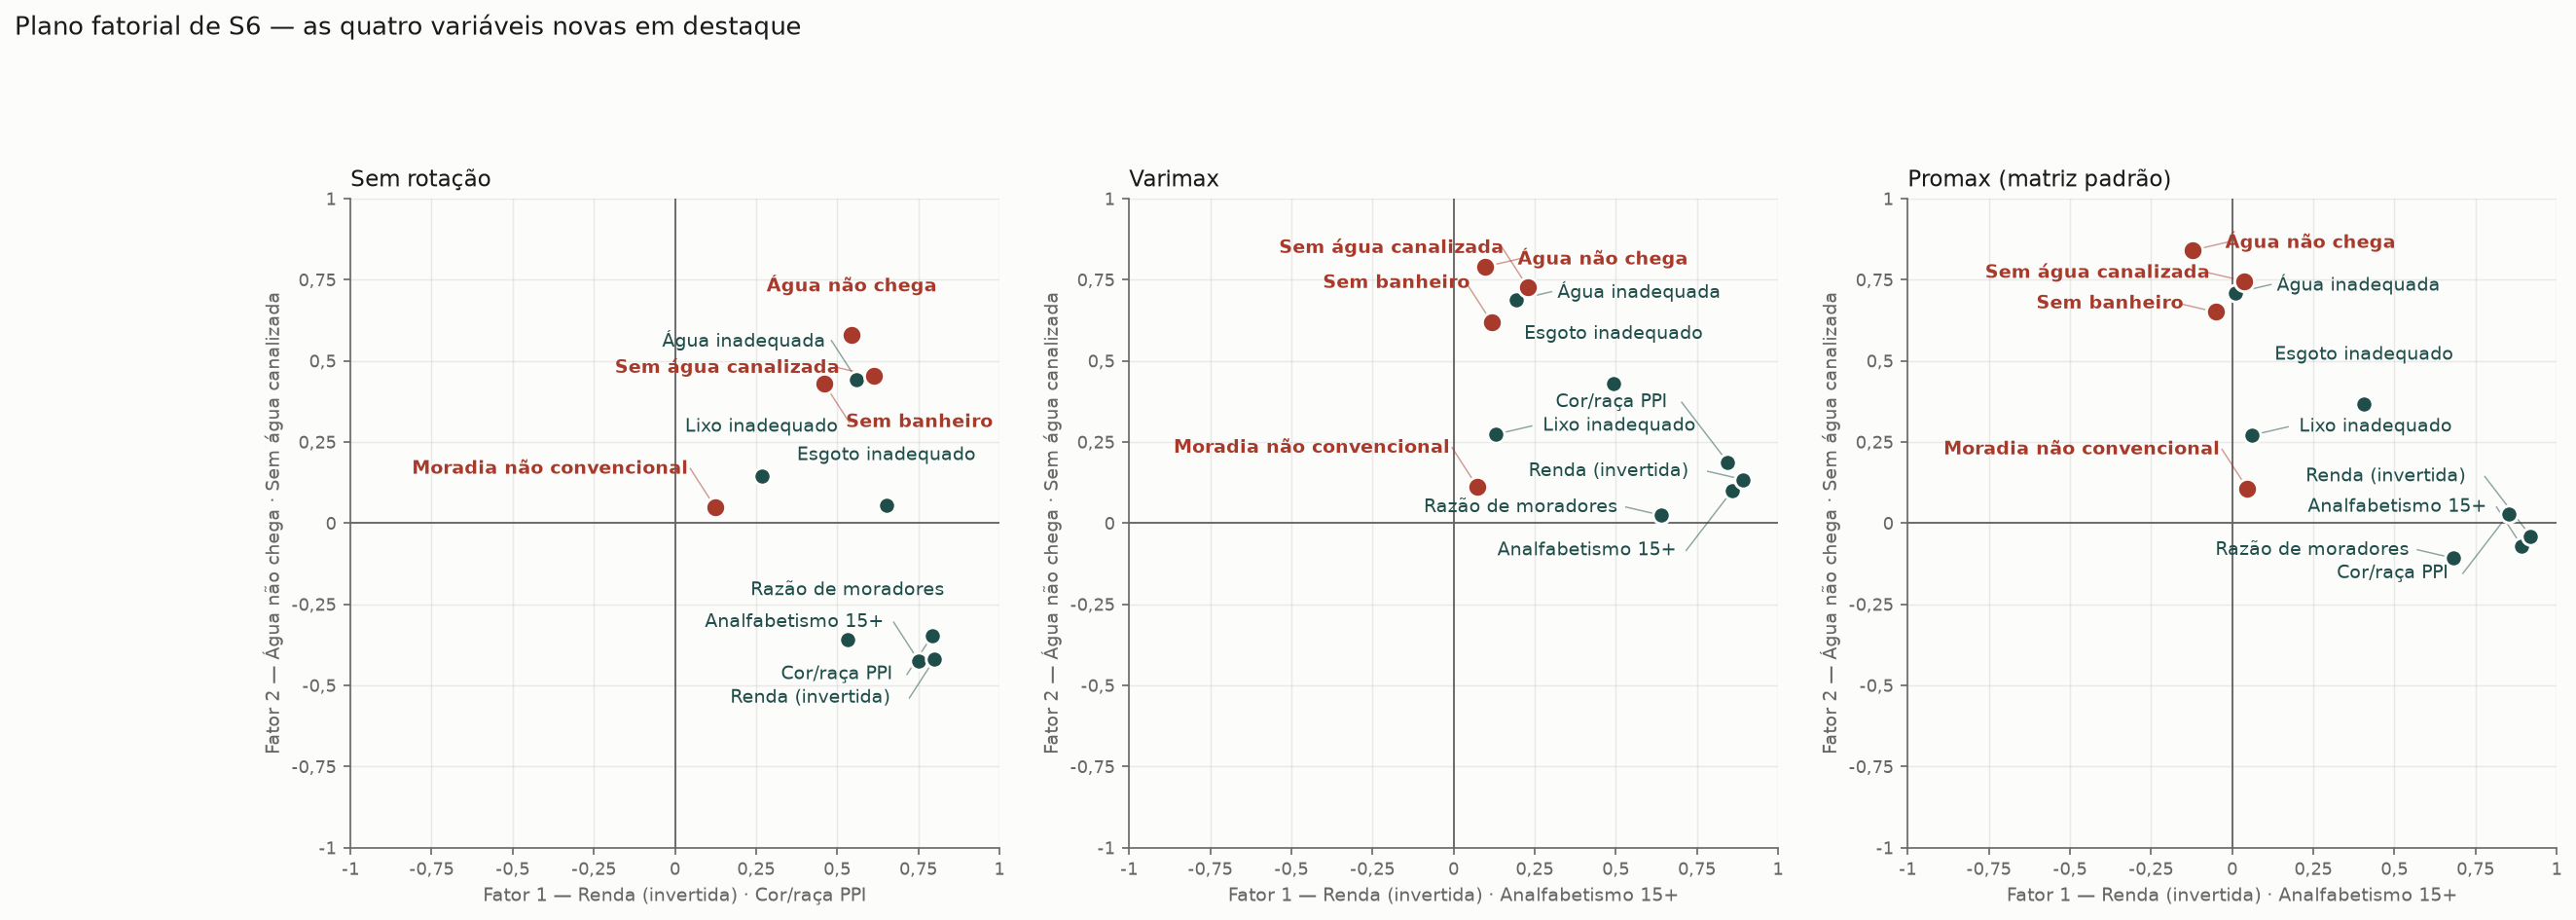

In [10]:
display(Image(filename=str(fa.FIG / 'fa_plano_s6.png')))


O painel acima (S6) mostra os mesmos pontos nas três soluções — sem rotação, Varimax e
promax pela matriz padrão. A posição de cada variável muda com a rotação, mas o agrupamento
(renda e as socioeconômicas de um lado; saneamento e habitação do outro) se mantém. O rótulo
de cada eixo sai das duas cargas de maior módulo naquele fator (NB4-08) — nunca é fixo.


## Bloco 4 — lixo (demanda 10)


In [11]:
cen[cen['cenario'].isin(['S0', 'S1', 'S5', 'S6', 'S7'])][['cenario', 'lixo_fator_proprio_varimax']]


,cenario,lixo_fator_proprio_varimax
0,S0,True
1,S1,None
5,S5,True
6,S6,False
7,S7,None


Com o IVS-7 sozinho (S0) e com a habitação não convencional somada (S5), o lixo fica isolado
num fator próprio na Varimax. Quando as quatro novas entram juntas (S6), deixa de ficar
sozinho — passa a dividir fator com outra variável de saneamento. S1 e S7 não têm lixo
(removido por desenho, a leitura da demanda 10) — por isso `NaN`.


In [12]:
for c in ['S0', 'S1', 'S6']:
    t = sens[(sens['cenario'] == c) & (sens['municipio_fora'] != '(nenhum)')]
    print(f"{c}: lixo muda de fator em {int(t['lixo_muda'].sum())} das {len(t)} rodadas "
          "(um município de fora por vez)")


S0: lixo muda de fator em 2 das 70 rodadas (um município de fora por vez)
S1: lixo muda de fator em 0 das 70 rodadas (um município de fora por vez)
S6: lixo muda de fator em 0 das 70 rodadas (um município de fora por vez)


Em S0, tirar um determinado município (das 70 rodadas) muda a posição do lixo em
2 delas — instável, mas raro. Em S1 e S6, o lixo nunca muda de fator ao
tirar um município (0 e 0 de 70). É
sensibilidade por município, não bootstrap (NB4-01): mostra o quanto um município específico
pesa, não um intervalo de confiança.


## Bloco 5 — a estrutura municipal (posto dentro do município)


In [13]:
comp_mun = pd.DataFrame({
    'cenario': ['S0', 'S1', 'S6'],
    'peso_f1_varimax_original': [pesos[(pesos.cenario == c) & (pesos.rotacao == 'varimax')]['peso_f1'].iloc[0]
                                  for c in ['S0', 'S1', 'S6']],
    'peso_f1_varimax_postos_mun': [pesos[(pesos.cenario == c + '_postos_mun') & (pesos.rotacao == 'varimax')]
                                    ['peso_f1'].iloc[0] for c in ['S0', 'S1', 'S6']],
})
comp_mun.round(2)


,cenario,peso_f1_varimax_original,peso_f1_varimax_postos_mun
0,S0,74.00,68.81
1,S1,65.01,71.43
2,S6,56.45,56.52


Rodar cada variável em posto percentil dentro do próprio município (tirando a diferença entre
cidades) muda o peso do primeiro fator sem uma direção única: cai em S0
(74,00 → 68,81), sobe em S1
(65,01 → 71,43) e quase não muda em S6
(56,45 → 56,52).


In [14]:
piv = valid.pivot(index='cenario', columns='medida', values='auc')
piv.loc[['S0', 'S0_postos_mun', 'S1', 'S1_postos_mun', 'S6', 'S6_postos_mun']].round(4)


medida,indice_01 (pesos Varimax),media simples de postos,renda invertida sozinha
cenario,,,
S0,0.8377,0.8684,0.8819
S0_postos_mun,0.8529,0.8178,0.8454
S1,0.8131,0.8533,0.8819
S1_postos_mun,0.8411,0.8133,0.8454
S6,0.8472,0.8694,0.8952
S6_postos_mun,0.8651,0.7555,0.8643


Sob a estrutura municipal, o índice supera a renda invertida sozinha em dois dos três casos
— S0 e S6 —, o que não acontece na escala original (Bloco 6, abaixo). Em S1 a renda continua
maior. É o único lugar, nesta análise, em que a ordem se inverte; fica registrado sem
adjetivo.


## Bloco 6 — o que o índice acrescenta à renda (NB4-02)


In [15]:
base_cenarios = [c[0] for c in fa.CENARIOS]
piv.loc[base_cenarios].round(4)


medida,indice_01 (pesos Varimax),media simples de postos,renda invertida sozinha
cenario,,,
S0,0.8377,0.8684,0.8819
S1,0.8131,0.8533,0.8819
S2,0.8384,0.8707,0.8889
S3,0.8365,0.8584,0.8819
S4,0.8568,0.8758,0.8897
S5,0.8379,0.8681,0.8819
S6,0.8472,0.8694,0.8952
S7,0.8394,0.8560,0.8952


In [16]:
sempre_maior = (piv.loc[base_cenarios, 'renda invertida sozinha'] > piv.loc[base_cenarios, 'indice_01 (pesos Varimax)']).all()
sempre_maior


np.True_

Em todos os oito cenários (S0 a S7), a AUC da renda invertida sozinha é maior que a do
índice — a célula acima confirma (`True`). A AUC mede o quanto a variável
ordena os setores de favela (FCU) acima dos demais; não valida pesos nem escolhe entre índice
e renda (NB4-02). Sob posto dentro do município (Bloco 5), essa ordem se inverte em dois dos
três casos. A decisão de qual entra no IVS final é do NB05 e da orientadora.


## Bloco 7 — o que fica para a orientadora decidir


In [17]:
piv.loc[['S0', 'S0_renda_sem_extremo', 'S0_renda_mediana_mun',
         'S6', 'S6_renda_sem_extremo', 'S6_renda_mediana_mun']].round(4)


medida,indice_01 (pesos Varimax),media simples de postos,renda invertida sozinha
cenario,,,
S0,0.8377,0.8684,0.8819
S0_renda_sem_extremo,0.8382,0.8684,0.8819
S0_renda_mediana_mun,0.8382,0.8684,0.8819
S6,0.8472,0.8694,0.8952
S6_renda_sem_extremo,0.8478,0.8694,0.8953
S6_renda_mediana_mun,0.8478,0.8694,0.8953


As três versões de renda (original, sem o setor extremo, imputada com a mediana municipal)
quase não mudam a AUC do índice nem da renda sozinha em S0 e em S6 — a diferença fica na 3ª
ou 4ª casa decimal. As três continuam lado a lado; a escolha é da orientadora (decisão 8 da
seção 2 do prompt).


In [18]:
zeros_novas = cargas[(cargas['cenario'] == 'S6') & (cargas['variavel'].isin(fa.NOVAS))][
    ['variavel', 'rotulo', 'pct_zeros']]
zeros_novas.round(1)


,variavel,rotulo,pct_zeros
52,pct_agua_nao_encanada,Água não chega,94.8
53,pct_sem_agua_canalizada,Sem água canalizada,77.1
54,pct_sem_banheiro,Sem banheiro,95.8
55,pct_moradia_nao_convencional,Moradia não convencional,92.9


As quatro variáveis novas têm entre 77,1% (sem água canalizada) e
95,8% (sem banheiro) de zeros **na base listwise de S6**
(69.458 setores com as quatro presentes) — não no recorte inteiro, que é maior (ver a
observação do README da pasta; os percentuais aqui não são os 85,7%/84,4% da seção 1 do
prompt, que usavam outro denominador). Com tantos zeros, o Spearman tem muitos empates e a
correlação fica achatada (NB4-05); é o cuidado que vale para toda carga dessas variáveis nas
tabelas dos blocos acima.


In [19]:
com_media = cargas.groupby('cenario')['comunalidade'].mean()
com_media.loc[base_cenarios].round(3)


cenario
S0    0.621
S1    0.700
S2    0.585
S3    0.592
S4    0.564
S5    0.544
S6    0.489
S7    0.532
Name: comunalidade, dtype: float64

A citação do livro usada no NB04 (p. 27 e 29) diz que o critério de Kaiser é **mais preciso**
quando n > 250 **e** comunalidade média ≥ 0,60 — as duas condições completas, não só uma
(NB4-04). O `n` de todo cenário passa de 250 sobrando; a comunalidade média, não: fica acima
de 0,60 em
S0, S1 e abaixo em
S2, S3, S4, S5, S6, S7. Onde fica
abaixo, a citação recomenda cautela extra com o critério de Kaiser — sem que isso decida a
favor ou contra os 2 fatores usados aqui (a decisão de quantos fatores reter é comparativa,
com Horn ao lado, não deste critério isolado).

Também ficam para a orientadora: a versão graduada de "sem banheiro" com V00237 (exige
reextração do NB01, pergunta 4 em aberto) e a manutenção da habitação não convencional na
grade apesar da variância baixa (mostrada, não excluída — demanda 9).


## Gravação e conferência

Grava os mesmos arquivos de `scripts/fatorial_ampliada.py::main()`, nos mesmos caminhos, com
`fa.gravar` — para confirmar que esta execução reproduz exatamente os CSVs da Fase 2 (mesmo
motor, mesmos dados). A conferência de identidade (`git status`) roda fora deste notebook.


In [20]:
fa.gravar(cen, 'cenarios.csv')
fa.gravar(cargas, 'cargas.csv')
fa.gravar(pesos, 'pesos.csv')
fa.gravar(valid, 'validacao_fcu.csv')
fa.gravar(autoval, 'autovalores.csv')
nomes6 = [fa.ROT[c] for c in res['S6']['colunas']]
fa.gravar(pd.DataFrame(res['S6']['r']['R'], index=nomes6, columns=nomes6)
          .rename_axis('variavel').reset_index(), 'correlacao_s6.csv')
fa.gravar(comp, 'comparacao_nao_chega_banheiro.csv')
fa.gravar(sens, 'sensibilidade_municipios.csv')
print('CSVs regravados em', fa.SAIDA)


CSVs regravados em /Users/pedro/Documents/Iniciacao Cientifica/Projeto_IVS_Censo22/banco_de_dados/eda/fatorial_ampliada
